In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import pvlib
from pvlib.location import Location

import pytz as pytz

import timezonefinder as tzf

from scipy.interpolate import interp1d
from scipy.optimize import brute
from scipy.integrate import solve_ivp

from tqdm import tqdm

import os

import Module_dynamics as dyn

In [19]:
#Map discretization/meshing 
#Creates a path object
Path = dyn.Path(name = 'CST0deg', type = 'A2A')

#Generate the Path() data: mapdata, TMY data, and horizon data
# Path.gen_mapdata(iterations=1)
Path.gen_mapdata_manual(slope = 0, lat = 45.51310015303088, long = -73.52733181478494)
Path.gen_TMY()
Path.gen_Horizon()



In [14]:
#testing code
capacity = 500
solararea = 0
power = 250

simtime = 60*60*0.25

# Initialize vehicle and environment
path = dyn.Path(name='CST-10deg', type='A2A')
env = dyn.Environment(path, StartDateTimeLocal='2025-06-15 08:00:00')
rider = dyn.Rider()
battery = dyn.Battery(capacity=capacity)
solarpanel = dyn.SolarPanel(area=solararea)
chassis = dyn.Chassis(mass=10, CdA=0.599631, Crr=0.004)
chassis.cargo_mass = 30
motor = dyn.Motor(RatedPower=power, efficiency=1)
vehicle = dyn.Vehicle(env, rider, battery, solarpanel, chassis, motor)

# Run simulation (will skip if results file exists)
dyn.simulate_fixedtimestep(vehicle, simtime_s=simtime, dt=1, SOC_i=0, output = "full")


simulating: 100%|██████████| 900/900 [00:04<00:00, 194.45it/s]


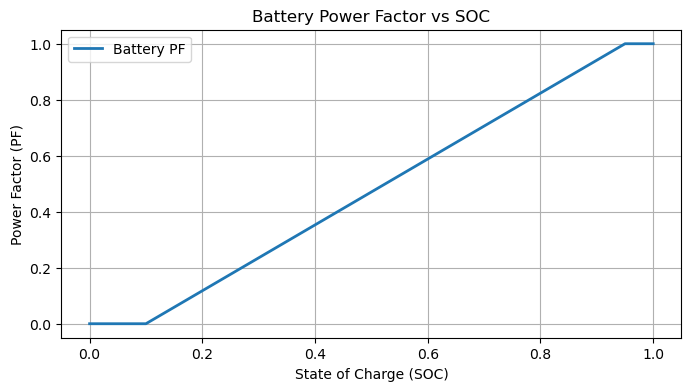

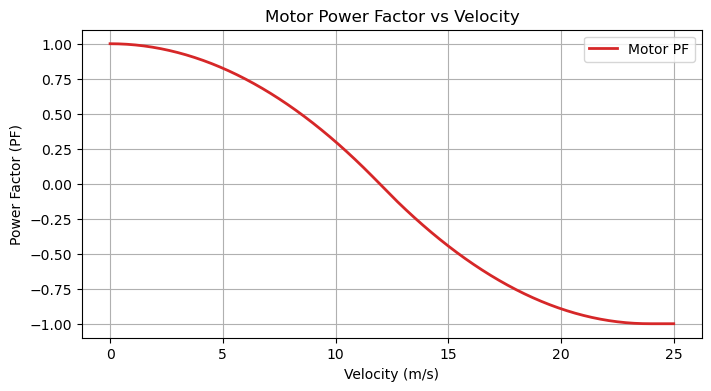

In [21]:
#plot battery and motor power factor functions from a vehicle object

#initialize a vehicle object
path = dyn.Path(name='PROTOUR', type='A2A')
env = dyn.Environment(path, StartDateTimeLocal='2025-06-15 00:00:00')
rider = dyn.Rider()
battery = dyn.Battery(capacity=500)
solarpanel = dyn.SolarPanel(area=1)
chassis = dyn.Chassis(mass=20, CdA=0.599631, Crr=0.004)
chassis.cargo_mass = 30
motor = dyn.Motor(RatedPower=250, efficiency=1)
vehicle = dyn.Vehicle(env, rider, battery, solarpanel, chassis, motor)

# Battery PF vs SOC as a smooth line
SOC_vals = np.linspace(0.0, 1.0, 201)            # denser grid for a smooth curve
pf_batt = np.array([vehicle.battery.__setattr__('SOC', s) or vehicle.battery.battery_Pf() for s in SOC_vals])
plt.figure(figsize=(8,4))
plt.plot(SOC_vals, pf_batt, '-', color='tab:blue', lw=2, label='Battery PF')
plt.title('Battery Power Factor vs SOC')
plt.xlabel('State of Charge (SOC)')
plt.ylabel('Power Factor (PF)')
plt.grid(True)
plt.legend()
plt.show()

# Motor PF vs Power as a smooth line
# choose motor power range (0..RatedPower or custom). using 0..power (variable defined above)
velocities = np.linspace(0.0, 25, 201)
pf_motor = np.array([vehicle.motor.motor_Pf(v) for v in velocities])
plt.figure(figsize=(8,4))
plt.plot(velocities, pf_motor, '-', color='tab:red', lw=2, label='Motor PF')
plt.title('Motor Power Factor vs Velocity')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Power Factor (PF)')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# Post processing
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.optimize import curve_fit
from collections import defaultdict

# set the folder that holds the data to be processed
filepath  = 'SIMRESULTS_CGV mid june light'

# Find all result files
files = glob(os.path.join(filepath, 'mass_*.csv'))

# Group files by (motor, battery, path), then subgroup by solar
main_groups = defaultdict(list)

for file in files:
    basename = os.path.basename(file)
    parts = basename.replace('.csv', '').split('_')
    mass = float(parts[1])
    motor = float(parts[3])
    solar = float(parts[5])
    battery = float(parts[7])
    path = '_'.join(parts[8:])
    key = (motor, battery, path)
    main_groups[key].append((solar, mass, file))

# Collect all unique solar values
all_solar = set()
for solar_mass_files in main_groups.values():
    for solar, mass, file in solar_mass_files:
        all_solar.add(solar)
all_solar = sorted(all_solar)
n_solar = len(all_solar)

fig, axes = plt.subplots(n_solar, 1, figsize=(7, 4 * n_solar), sharex=True)
if n_solar == 1:
    axes = [axes]  # Ensure axes is always iterable

for i, solar in enumerate(all_solar):
    ax = axes[i]
    for key, solar_mass_files in main_groups.items():
        # Find all mass sweeps for this solar value
        mass_files = [(mass, file) for s, mass, file in solar_mass_files if s == solar]
        if not mass_files:
            continue
        mass_files.sort()
        masses = []
        avg_speeds = []
        for mass, file in mass_files:
            with open(file, 'rb') as f:
                try:
                    f.seek(-2, os.SEEK_END)
                    while f.read(1) != b'\n':
                        f.seek(-2, os.SEEK_CUR)
                except OSError:
                    f.seek(0)
                last_line = f.readline().decode()
            columns = last_line.strip().split(',')
            distance = float(columns[1])
            avg_speed = distance/(15*8*60*60)
            masses.append(mass)
            avg_speeds.append(avg_speed)
        masses = np.array(masses)
        avg_speeds = np.array(avg_speeds)
        # Scatter plot for each (motor, battery, path) at this solar value
        ax.scatter(masses, avg_speeds, label=f'Motor={key[0]}, Battery={key[1]}, Path={key[2]}')
        # Linear fit
        if len(masses) >= 2:
            lin_coeffs = np.polyfit(masses, avg_speeds, 1)
            lin_fit = np.polyval(lin_coeffs, masses)
            lin_label = (f'Linear fit\n'
                         r'$y = {:.5f}x {:+.3f}$'.format(lin_coeffs[0], lin_coeffs[1]))
            ax.plot(masses, lin_fit, '--', label=lin_label)
        # Quadratic fit
        if len(masses) >= 3:
            quad_coeffs = np.polyfit(masses, avg_speeds, 2)
            quad_fit = np.polyval(quad_coeffs, masses)
            quad_label = (f'Quad fit\n'
                          r'$y = {:.5f}x^2 {:+.3f}x {:+.3f}$'.format(
                              quad_coeffs[0], quad_coeffs[1], quad_coeffs[2]))
            # ax.plot(masses, quad_fit, ':', label=quad_label)
    ax.set_title(f'Solar = {solar}')
    ax.set_xlabel('Mass (kg)')
    ax.set_ylabel('Average Speed (m/s)')
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Merlin\AppData\Local\Temp\ipykernel_22932\1770762418.py:13: SyntaxWarning: invalid escape sequence '\m'
  filepath = 'SIMRESULTS\mass_110.0_motor_250_solar_0.0_battery_500.0_CST-10deg.csv'


shapes: (37,) (37,) (37,) (37,) (37,)
time (s) min/max: 0.0 36.0
position min/max: 0.2 652.7525428640819
speed min/max: 6.207669205417759 21.387835771067653
SOC min/max: 0.0 0.0035908355138740936
motor power min/max: -238.78657139046467 0.0


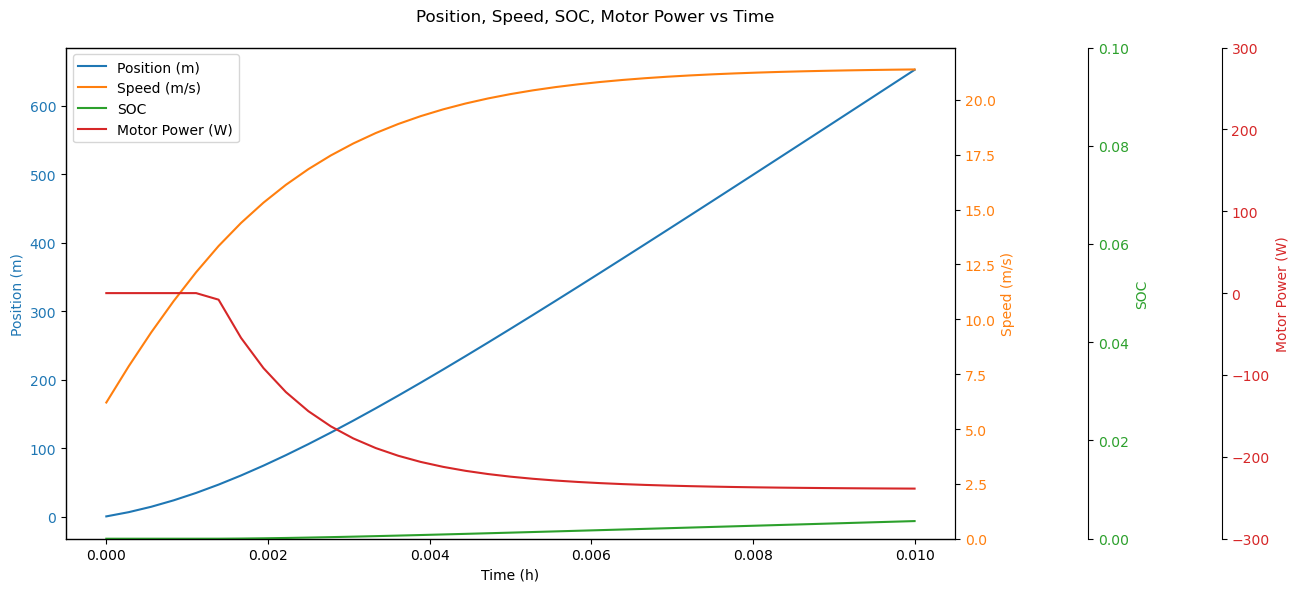

In [19]:
# Post processing one simulation result file
# plot interest variables: position, speed, acceleration, SOC, motor power against time and against distance

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.optimize import curve_fit
from collections import defaultdict

#set the file to be processed
filepath = 'SIMRESULTS\mass_110.0_motor_250_solar_0.0_battery_500.0_CST-10deg.csv'
data = pd.read_csv(filepath)

time = pd.to_numeric(data['simtime'], errors='coerce').to_numpy()
position = pd.to_numeric(data['Distance'], errors='coerce').to_numpy()
speed = pd.to_numeric(data['Velocity'], errors='coerce').to_numpy()
Energy = pd.to_numeric(data['Energy'], errors='coerce').to_numpy()
motor_power = pd.to_numeric(data['Motorpower'], errors='coerce').to_numpy()

# capacity -> scalar
cap = float(getattr(vehicle.battery, 'capacity', vehicle.battery.capacity))

SOC = Energy / (cap * 3600.0)

# choose time window (seconds)
t_min = 0.0   # set as needed
t_max = 0.01*60*60 # or set custom

mask = (time >= t_min) & (time <= t_max)
time_plot = time[mask]
time_h = time_plot / 3600.0

position_plot = position[mask]
speed_plot = speed[mask]
SOC_plot = SOC[mask]
motor_power_plot = motor_power[mask]

# quick diagnostics
print("shapes:", time_plot.shape, position_plot.shape, speed_plot.shape, SOC_plot.shape, motor_power_plot.shape)
print("time (s) min/max:", np.nanmin(time_plot), np.nanmax(time_plot))
print("position min/max:", np.nanmin(position_plot), np.nanmax(position_plot))
print("speed min/max:", np.nanmin(speed_plot), np.nanmax(speed_plot))
print("SOC min/max:", np.nanmin(SOC_plot), np.nanmax(SOC_plot))
print("motor power min/max:", np.nanmin(motor_power_plot), np.nanmax(motor_power_plot))


fig, ax1 = plt.subplots(figsize=(12, 6))

# use time in hours for all x
ax1.plot(time_h, position_plot, color='tab:blue', label='Position (m)')
ax1.set_ylabel('Position (m)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(time_h, speed_plot, color='tab:orange', label='Speed (m/s)')
ax2.set_ylabel('Speed (m/s)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.15))
ax3.plot(time_h, SOC_plot, color='tab:green', label='SOC')
ax3.set_ylabel('SOC', color='tab:green')
ax3.tick_params(axis='y', labelcolor='tab:green')
ax3.set_ylim(0.0, 1.0)

ax4 = ax1.twinx()
ax4.spines.right.set_position(("axes", 1.3))
ax4.plot(time_h, motor_power_plot, color='tab:red', label='Motor Power (W)')
ax4.set_ylabel('Motor Power (W)', color='tab:red')
ax4.tick_params(axis='y', labelcolor='tab:red')

# set y-limits: Speed from 0 to max observed speed
ax2.set_ylim(0, max(speed_plot)+1)
# set y-limits: SOC in [0,1]; motor power symmetric around zero
ax3.set_ylim(0.0, 0.1)

# prefer motor rated power if vehicle object exists, otherwise use observed max
try:
    mp_lim = float(vehicle.motor.RatedPower)
except Exception:
    mp_lim = max(1.0, np.nanmax(np.abs(motor_power_plot)))
ax4.set_ylim(-mp_lim-50, mp_lim+50)

# set xlabel in hours and tidy x-ticks (integer hours)
ax1.set_xlabel('Time (h)')
h_min, h_max = np.nanmin(time_h), np.nanmax(time_h)
if np.isfinite(h_min) and np.isfinite(h_max):
    # choose integer tick spacing when span > 1h, else default ticks
    span_h = h_max - h_min
    if span_h > 1.0:
        ticks = np.arange(np.floor(h_min), np.ceil(h_max) + 1, 1.0)
        ax1.set_xticks(ticks)
        ax1.set_xlim(h_min, h_max)

fig.suptitle('Position, Speed, SOC, Motor Power vs Time')
fig.tight_layout()
fig.subplots_adjust(right=0.8)

# combined legend
lines, labels = [], []
for ax in [ax1, ax2, ax3, ax4]:
    l, lab = ax.get_legend_handles_labels()
    lines += l; labels += lab
ax1.legend(lines, labels, loc='upper left')

plt.show()


2025-06-15 24h full day
129.0 kg total mass with 0.5m2 of PV and 500Wh: final distance =  218754.13932084545
avg = 27.329129855
133.0 kg total mass with 1m2 of PV and 500Wh: final distance =  240922.05717548906
avg = 30.115257125

Convergence study on dynamic simulation only (no pv/battery system)
final distance dt 0.1s =  162561.67956226136
final distance dt 0.5s =  162924.8161293678
final distance dt 1s   =  163407.0717180171
final distance dt 2s   =  164233.00078083167
final distance dt 5s   =  168806.842612409
final distance dt 10s  =  180447.25261423894 traces vs time and position do not reflect nicely the cyclic laps of CGV
final distance dt 15s  =  796045.1965056054  traces vs time and position are completely not as expected

In [ ]:
#visually look at data grids to debug mesher
Path = dyn.Path('CGV', 'A2A')

Path.get_mapdata()
Path.gen_TMY()
Path.gen_Horizon()

def get_grid_ids(horizon_folder):
    grid_ids = []
    for fname in os.listdir(horizon_folder):
        if fname.endswith('_Horizon.csv'):
            grid_id = fname.replace('_Horizon.csv', '')
            latID, longID = map(int, grid_id.split(';'))
            grid_ids.append((latID, longID))
    return np.array(grid_ids)

# Get grid IDs for both folders
folder1 = 'CGV_original/Horizon'
folder2 = 'CGV/Horizon'

grids1 = get_grid_ids(folder1)
grids2 = get_grid_ids(folder2)
mapdata = Path.get_mapdata()
Horizon_GridIDs =  mapdata['Horizon_GridID'].unique()
grids3 = np.array([(int(grid.split(';')[0]), int(grid.split(';')[1])) for grid in Horizon_GridIDs])
print(grids3)
plt.figure(figsize=(10, 6))
plt.scatter(grids1[:,1], grids1[:,0], label='CGV_original', marker='o', color='blue')
plt.scatter(grids2[:,1], grids2[:,0], label='CGV', marker='x', color='red')
plt.scatter(grids3[:,1], grids3[:,0], label='Mapdata', marker ='^', color='green')
plt.xlabel('longID')
plt.ylabel('latID')
plt.title('Horizon Grid Coverage')
plt.legend()
plt.grid(True)
plt.show()